# CSE475 — Task 2: Proposed Model (Graph Neural Network) — EMG + Glove
## Track 1 — GNN on NinaPro DB1 (Classification)

Dataset: `/kaggle/input/datasets/hoixding/nianpro-db1`.

**Design change from the EMG-only version:** this notebook includes glove (kinematic)
channels as additional graph nodes, alongside the 10 EMG channels — for a directly
comparable number against the classical baselines (which also used EMG+glove). The
correlation-based graph now spans all 32 channels (10 EMG + 22 glove).


## 1. Install and Import PyTorch Geometric

In [1]:
!pip install torch_geometric -q

import os
import glob
import time
import numpy as np
import pandas as pd
from collections import Counter
from scipy.io import loadmat

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              precision_recall_fscore_support, confusion_matrix,
                              classification_report, roc_auc_score, average_precision_score)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
RANDOM_STATE = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.7 MB/s eta 0:00:00
Using device: cuda


## 2. Load Raw Data and Extract EMG + Glove Windowed Features

Same windowing (`WINDOW_SIZE=200`, `STEP_SIZE=100`, grouped by subject/exercise/
repetition/gesture, rest excluded) and same subject split (1–20 train, 21–27 test) as
the baselines notebook. All 32 channels (10 EMG + 22 glove) are used as graph nodes.

In [2]:
DATASET_PATH = "/kaggle/input/datasets/hoixding/nianpro-db1"
mat_files = sorted(glob.glob(os.path.join(DATASET_PATH, "s*", "*.mat")))
print(f"Total MAT files: {len(mat_files)}")

EMG_CHANNELS = [f"emg_{i}" for i in range(10)]
GLOVE_CHANNELS = [f"glove_{i}" for i in range(22)]
ALL_CHANNELS = EMG_CHANNELS + GLOVE_CHANNELS

all_data = []
for file in mat_files:
    mat = loadmat(file)
    emg = pd.DataFrame(mat["emg"], columns=EMG_CHANNELS)
    glove = pd.DataFrame(mat["glove"], columns=GLOVE_CHANNELS)
    df = pd.concat([emg, glove], axis=1)
    df["restimulus"] = mat["restimulus"].flatten()
    df["repetition"] = mat["repetition"].flatten()
    subject = int(os.path.basename(os.path.dirname(file)).replace("s",""))
    df["subject"] = subject
    exercise = int(file.split("_E")[-1].split(".")[0])
    df["exercise"] = exercise
    all_data.append(df)

dataset = pd.concat(all_data, ignore_index=True)
print(f"Dataset shape (EMG + glove): {dataset.shape}")

Total MAT files: 81
Dataset shape (EMG + glove): (12553611, 36)


In [3]:
WINDOW_SIZE = 200
STEP_SIZE = 100

def rms(x): return np.sqrt(np.mean(x**2))
def mav(x): return np.mean(np.abs(x))
def wl(x):  return np.sum(np.abs(np.diff(x)))
def var(x): return np.var(x)

print("Extracting EMG + glove windowed features for the GNN...")
node_features = []   # will hold (n_channels x 4) arrays, one per window
labels = []
subjects = []

for (subject, exercise, repetition, gesture), group in dataset.groupby(
    ["subject", "exercise", "repetition", "restimulus"]
):
    if gesture == 0:
        continue
    group = group.reset_index(drop=True)
    if len(group) < WINDOW_SIZE:
        continue
    for start in range(0, len(group) - WINDOW_SIZE + 1, STEP_SIZE):
        window = group.iloc[start:start+WINDOW_SIZE]
        ch_feats = []
        for ch in ALL_CHANNELS:
            sig = window[ch].values
            ch_feats.append([rms(sig), mav(sig), wl(sig), var(sig)])
        node_features.append(np.array(ch_feats, dtype=np.float32))  # (32, 4)
        labels.append(gesture)
        subjects.append(subject)

node_features = np.array(node_features)  # (n_windows, 32, 4)
labels = np.array(labels)
subjects = np.array(subjects)
print(f"Total windows: {len(labels)} | Node feature tensor shape: {node_features.shape}")

Extracting EMG + glove windowed features for the GNN...
Total windows: 30936 | Node feature tensor shape: (30936, 32, 4)


## 3. Train/Test Split (Subject-Independent, Matching Baselines) and Scaling

In [4]:
train_mask = (subjects >= 1) & (subjects <= 20)
test_mask = (subjects >= 21) & (subjects <= 27)

X_train_raw = node_features[train_mask]   # (n_train, 32, 4)
X_test_raw = node_features[test_mask]
y_train_raw = labels[train_mask]
y_test_raw = labels[test_mask]

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

n_channels, feats_per_channel = X_train_raw.shape[1], X_train_raw.shape[2]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw.reshape(len(X_train_raw), -1)).reshape(X_train_raw.shape)
X_test_scaled = scaler.transform(X_test_raw.reshape(len(X_test_raw), -1)).reshape(X_test_raw.shape)

print(f"Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")
print(f"Classes: {list(le.classes_)} ({len(le.classes_)} total)")

Train: (22724, 32, 4) | Test: (8212, 32, 4)
Classes: [np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23)] (23 total)


## 3b. Class Balancing — Oversample Minority Classes

Structured equivalent of the baselines' SMOTE step: SMOTE's linear interpolation
doesn't apply cleanly to structured (channel x feature) node tensors, so random
oversampling with replacement is used instead to match the majority class count.

In [5]:
print("Before oversampling:", dict(sorted(Counter(y_train).items())))

max_count = max(Counter(y_train).values())
X_resampled, y_resampled = [], []
for cls in np.unique(y_train):
    cls_idx = np.where(y_train == cls)[0]
    boosted_idx = resample(cls_idx, replace=True, n_samples=max_count, random_state=RANDOM_STATE)
    X_resampled.append(X_train_scaled[boosted_idx])
    y_resampled.append(y_train[boosted_idx])

X_train_scaled = np.concatenate(X_resampled, axis=0)
y_train = np.concatenate(y_resampled, axis=0)
print("After oversampling:", dict(sorted(Counter(y_train).items())))

Before oversampling: {np.int64(0): 1320, np.int64(1): 1259, np.int64(2): 1299, np.int64(3): 1209, np.int64(4): 1205, np.int64(5): 1259, np.int64(6): 1269, np.int64(7): 1315, np.int64(8): 1228, np.int64(9): 1228, np.int64(10): 1291, np.int64(11): 1281, np.int64(12): 840, np.int64(13): 820, np.int64(14): 859, np.int64(15): 942, np.int64(16): 988, np.int64(17): 513, np.int64(18): 506, np.int64(19): 547, np.int64(20): 472, np.int64(21): 485, np.int64(22): 589}
After oversampling: {np.int64(0): 1320, np.int64(1): 1320, np.int64(2): 1320, np.int64(3): 1320, np.int64(4): 1320, np.int64(5): 1320, np.int64(6): 1320, np.int64(7): 1320, np.int64(8): 1320, np.int64(9): 1320, np.int64(10): 1320, np.int64(11): 1320, np.int64(12): 1320, np.int64(13): 1320, np.int64(14): 1320, np.int64(15): 1320, np.int64(16): 1320, np.int64(17): 1320, np.int64(18): 1320, np.int64(19): 1320, np.int64(20): 1320, np.int64(21): 1320, np.int64(22): 1320}


## 4. (A) Graph Construction — EMG + Glove Nodes

**Nodes:** all 32 channels (10 EMG + 22 glove) are nodes.
**Edges:** built from pairwise correlation between channels, computed only on the
**training set** (§6.2). Edge weight uses `abs(correlation)` — `GCNConv`'s degree
normalization requires non-negative weights; using signed correlation was the root
cause of the earlier training collapse.
**Node features:** RMS, MAV, WL, VAR per channel per window.

**Why include glove here:** for a directly comparable number to the classical
baselines (which also use EMG+glove). This is a deliberate scoping choice, not the
"real-world" EMG-only formulation — see the note at the top of this notebook.

Graph: 32 nodes, 184 / 992 possible directed edges
Edge weight range: [0.300, 0.878] (should be >= 0)


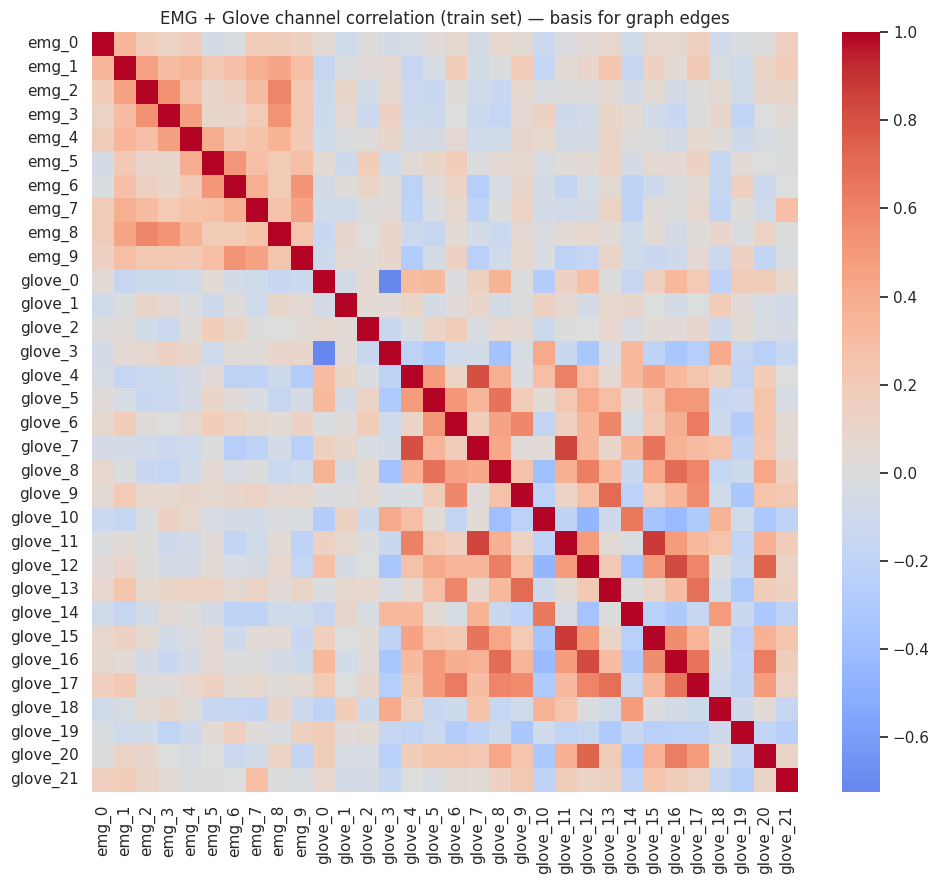

In [6]:
channel_proxy = pd.DataFrame(X_train_raw[:, :, 0], columns=ALL_CHANNELS)  # raw (unscaled) RMS, for interpretability
corr_matrix = channel_proxy.corr().values

THRESHOLD = 0.3
adj = (np.abs(corr_matrix) > THRESHOLD).astype(float)
np.fill_diagonal(adj, 0)
edge_index = np.array(np.nonzero(adj))

# FIX: absolute correlation as edge weight (non-negative, required by GCNConv normalization)
edge_weight = np.abs(corr_matrix[edge_index[0], edge_index[1]])

edge_index = torch.tensor(edge_index, dtype=torch.long)
edge_weight = torch.tensor(edge_weight, dtype=torch.float)

n_possible_edges = n_channels * (n_channels - 1)
print(f"Graph: {n_channels} nodes, {edge_index.shape[1]} / {n_possible_edges} possible directed edges")
print(f"Edge weight range: [{edge_weight.min():.3f}, {edge_weight.max():.3f}] (should be >= 0)")
if edge_index.shape[1] < n_channels:
    print("WARNING: graph is very sparse -- consider lowering THRESHOLD")

plt.figure(figsize=(10, 9))
sns.heatmap(corr_matrix, xticklabels=ALL_CHANNELS, yticklabels=ALL_CHANNELS, cmap="coolwarm", center=0)
plt.title("EMG + Glove channel correlation (train set) — basis for graph edges")
plt.tight_layout()
plt.show()

## 5. Build PyG `Data` Objects — One Graph per Window

In [7]:
def row_to_graph(node_feat_matrix, label):
    x = torch.tensor(node_feat_matrix, dtype=torch.float)  # (32, 4)
    y_t = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y_t)

train_graphs = [row_to_graph(X_train_scaled[i], y_train[i]) for i in range(len(y_train))]
test_graphs = [row_to_graph(X_test_scaled[i], y_test[i]) for i in range(len(y_test))]

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)

print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")
print("Example graph:", train_graphs[0])

Train graphs: 30360 | Test graphs: 8212
Example graph: Data(x=[32, 4], edge_index=[2, 184], edge_attr=[184], y=[1])


## 6. (B) Architecture & (C) Explanation

**Architecture diagram (in words):**
`Input window (32 channels x 4 descriptors) → correlation-based graph →
learnable edge-refinement → GCN layer 1 → BN → ReLU → GCN layer 2 → BN → ReLU →
GCN layer 3 → BN → ReLU → mean pooling (readout) → linear classifier → gesture class`

**In our own words:** each of the 32 channels (10 muscle + 22 joint-angle sensors) is a
node carrying 4 numbers describing its activity in the current window. We start from a
correlation-based graph — built once, from training data only — and let a small MLP
learn to adjust each edge's importance during training. Three GCN layers (deeper than
the EMG-only version) let information propagate further across this larger, more
heterogeneous graph, since EMG and glove channels relate to each other differently than
EMG channels relate to one another. Mean-pooling combines all 32 channel embeddings into
one window-level representation, classified into a gesture by the final linear layer.

In [8]:
class EdgeRefineGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.3):
        super().__init__()
        self.edge_refine = nn.Sequential(
            nn.Linear(1, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid()
        )
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_attr, batch):
        refined_weight = self.edge_refine(edge_attr.unsqueeze(-1)).squeeze(-1) * edge_attr

        h = self.conv1(x, edge_index, edge_weight=refined_weight)
        h = self.bn1(h); h = F.relu(h); h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.conv2(h, edge_index, edge_weight=refined_weight)
        h = self.bn2(h); h = F.relu(h); h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.conv3(h, edge_index, edge_weight=refined_weight)
        h = self.bn3(h); h = F.relu(h)

        h = global_mean_pool(h, batch)
        return self.classifier(h)

num_classes = len(le.classes_)
model = EdgeRefineGCN(in_channels=feats_per_channel, hidden_channels=64, num_classes=num_classes).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

EdgeRefineGCN(
  (edge_refine): Sequential(
    (0): Linear(in_features=1, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
    (3): Sigmoid()
  )
  (conv1): GCNConv(4, 64)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(64, 64)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GCNConv(64, 64)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Linear(in_features=64, out_features=23, bias=True)
)

Total parameters: 10,544


## 7. Training Setup, Loop, and Evaluation

In [9]:
# No class_weight needed -- oversampling in Section 3b already balances the training set
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

In [10]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels, all_proba = 0, [], [], []

    for batch in loader:
        batch = batch.to(device)
        if train:
            optimizer.zero_grad()

        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        proba = F.softmax(out, dim=1).detach().cpu().numpy()
        all_proba.append(proba)
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    all_proba = np.concatenate(all_proba, axis=0)
    return avg_loss, f1, all_preds, all_labels, all_proba

EPOCHS = 100
history = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}
best_val_f1 = 0
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1, _, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_f1, _, _, _ = run_epoch(test_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss); history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss); history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_gnn_model.pth")

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss {train_loss:.4f} F1 {train_f1:.4f} | Val Loss {val_loss:.4f} F1 {val_f1:.4f}")

gnn_train_time = time.time() - start_time
print(f"\nBest validation Macro-F1: {best_val_f1:.4f} | Total training time: {gnn_train_time:.1f}s")

if best_val_f1 < 0.25:
    print("\nWARNING: Macro-F1 is still very low. If this persists, check:")
    print("  1. Print the edge_weight tensor -- confirm no NaN/negative values")
    print("  2. Try lowering THRESHOLD in Section 4 (e.g. to 0.15) for a denser graph")
    print("  3. Try lowering the learning rate to 5e-4 if train_loss is oscillating, not decreasing")

Epoch 001 | Train Loss 2.6220 F1 0.1865 | Val Loss 2.5656 F1 0.2164
Epoch 010 | Train Loss 1.8875 F1 0.3905 | Val Loss 2.2736 F1 0.3119
Epoch 020 | Train Loss 1.7199 F1 0.4477 | Val Loss 2.2079 F1 0.3550
Epoch 030 | Train Loss 1.6511 F1 0.4694 | Val Loss 2.1528 F1 0.3716
Epoch 040 | Train Loss 1.6318 F1 0.4746 | Val Loss 2.1124 F1 0.3838
Epoch 050 | Train Loss 1.6155 F1 0.4801 | Val Loss 2.1610 F1 0.3710
Epoch 060 | Train Loss 1.5960 F1 0.4897 | Val Loss 2.0863 F1 0.3853
Epoch 070 | Train Loss 1.5908 F1 0.4889 | Val Loss 2.0871 F1 0.3870
Epoch 080 | Train Loss 1.5916 F1 0.4888 | Val Loss 2.0810 F1 0.3907
Epoch 090 | Train Loss 1.5900 F1 0.4878 | Val Loss 2.1235 F1 0.3796
Epoch 100 | Train Loss 1.5874 F1 0.4934 | Val Loss 2.0858 F1 0.3876

Best validation Macro-F1: 0.3925 | Total training time: 763.6s


### Training Curves

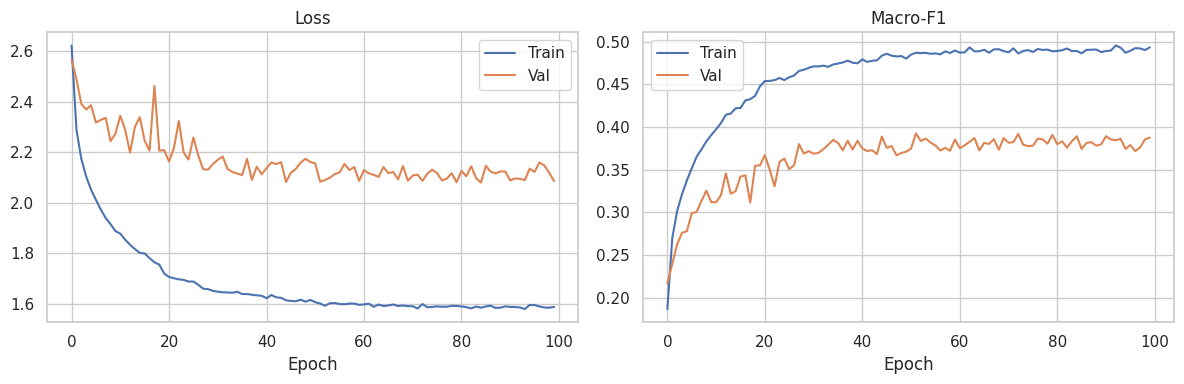

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train"); axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["train_f1"], label="Train"); axes[1].plot(history["val_f1"], label="Val")
axes[1].set_title("Macro-F1"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Final Test Evaluation — Full Metric Set

GNN Test Accuracy: 0.3699
GNN Test Macro-F1: 0.3925 | Weighted-F1: 0.3607
GNN Macro-Precision: 0.4024 | Macro-Recall: 0.4374
GNN ROC-AUC (macro, OvR): 0.8826 | PR-AUC (macro, OvR): 0.4230

GNN prediction distribution (class : count): {np.uint8(1): np.int64(317), np.uint8(2): np.int64(379), np.uint8(3): np.int64(424), np.uint8(4): np.int64(508), np.uint8(5): np.int64(273), np.uint8(6): np.int64(386), np.uint8(7): np.int64(244), np.uint8(8): np.int64(476), np.uint8(9): np.int64(207), np.uint8(10): np.int64(169), np.uint8(11): np.int64(309), np.uint8(12): np.int64(252), np.uint8(13): np.int64(339), np.uint8(14): np.int64(286), np.uint8(15): np.int64(396), np.uint8(16): np.int64(481), np.uint8(17): np.int64(483), np.uint8(18): np.int64(499), np.uint8(19): np.int64(770), np.uint8(20): np.int64(450), np.uint8(21): np.int64(134), np.uint8(22): np.int64(216), np.uint8(23): np.int64(214)}


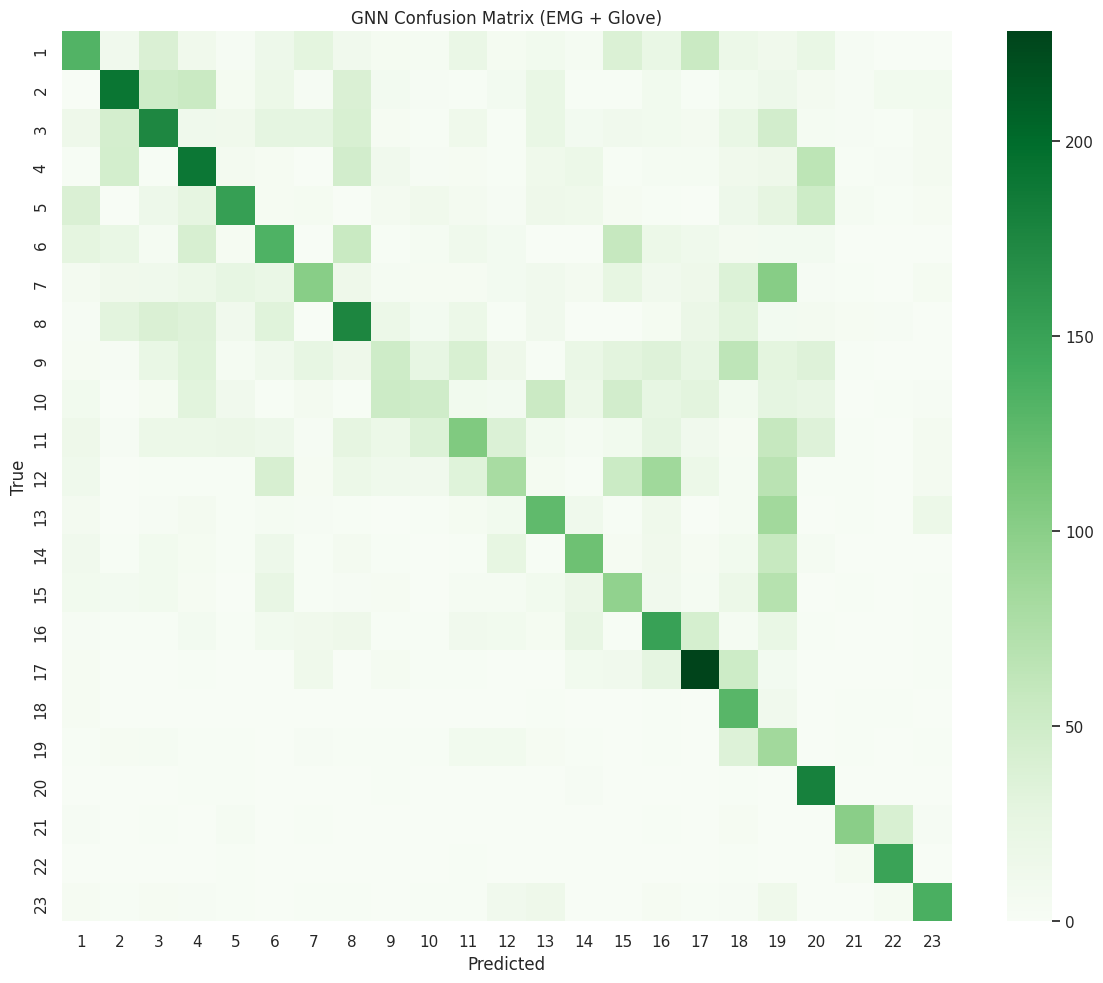

              precision    recall  f1-score   support

           1       0.42      0.28      0.33       480
           2       0.50      0.40      0.45       475
           3       0.41      0.34      0.37       522
           4       0.37      0.41      0.39       461
           5       0.56      0.37      0.44       415
           6       0.35      0.31      0.33       431
           7       0.41      0.22      0.29       451
           8       0.37      0.38      0.37       465
           9       0.24      0.10      0.14       496
          10       0.29      0.12      0.16       426
          11       0.34      0.22      0.27       485
          12       0.32      0.17      0.23       466
          13       0.37      0.41      0.39       307
          14       0.41      0.40      0.40       292
          15       0.24      0.31      0.27       306
          16       0.31      0.45      0.37       332
          17       0.47      0.62      0.54       365
          18       0.26    

In [12]:
model.load_state_dict(torch.load("best_gnn_model.pth"))
_, gnn_macro_f1, test_preds, test_labels, test_proba = run_epoch(test_loader, train=False)

gnn_acc = accuracy_score(test_labels, test_preds)
gnn_macro_prec, gnn_macro_rec, _, _ = precision_recall_fscore_support(test_labels, test_preds, average='macro', zero_division=0)
gnn_weighted_f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)

gnn_classes = sorted(np.unique(test_labels))
y_test_bin = label_binarize(test_labels, classes=gnn_classes)
try:
    gnn_roc_auc = roc_auc_score(y_test_bin, test_proba, average='macro', multi_class='ovr')
    gnn_pr_auc = average_precision_score(y_test_bin, test_proba, average='macro')
except Exception:
    gnn_roc_auc, gnn_pr_auc = None, None

print(f"GNN Test Accuracy: {gnn_acc:.4f}")
print(f"GNN Test Macro-F1: {gnn_macro_f1:.4f} | Weighted-F1: {gnn_weighted_f1:.4f}")
print(f"GNN Macro-Precision: {gnn_macro_prec:.4f} | Macro-Recall: {gnn_macro_rec:.4f}")
print(f"GNN ROC-AUC (macro, OvR): {gnn_roc_auc:.4f} | PR-AUC (macro, OvR): {gnn_pr_auc:.4f}")

unique, counts = np.unique(test_preds, return_counts=True)
print("\nGNN prediction distribution (class : count):", dict(zip(le.classes_[unique], counts)))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Greens", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("GNN Confusion Matrix (EMG + Glove)")
plt.tight_layout()
plt.show()

print(classification_report(test_labels, test_preds, target_names=[str(c) for c in le.classes_], zero_division=0))

## 9. First Results — Compare to Baselines

Update `INPUT_DIR` to your attached baselines notebook's output path.

In [13]:
INPUT_DIR = "/kaggle/input/notebooks/afiamahpara/group04-ninaprodb1-task2-baselines80969d129d"  

baseline_macro_df = pd.read_csv(f"{INPUT_DIR}/Baseline_Macro_Results.csv")

gnn_row = pd.DataFrame([{
    "Model": "Proposed GNN (EMG + Glove)",
    "Macro-Precision": gnn_macro_prec, "Macro-Recall": gnn_macro_rec, "Macro-F1": gnn_macro_f1,
    "ROC-AUC (macro, OvR)": gnn_roc_auc, "PR-AUC (macro, OvR)": gnn_pr_auc
}])

final_comparison = pd.concat([baseline_macro_df, gnn_row], ignore_index=True).sort_values("Macro-F1", ascending=False)
print(final_comparison.round(4))

best_overall = final_comparison.iloc[0]["Model"]
print(f"\nBest model overall (first results, by Macro-F1): {best_overall}")

                        Model  Macro-Precision  Macro-Recall  Macro-F1  \
0                   SVM (rbf)           0.7906        0.7879    0.7842   
1               Random Forest           0.7572        0.7576    0.7514   
2                    LightGBM           0.7668        0.7467    0.7480   
3                     XGBoost           0.7601        0.7392    0.7400   
4                         MLP           0.7185        0.7106    0.7031   
5                  k-NN (k=7)           0.6876        0.7018    0.6903   
6         Logistic Regression           0.6869        0.6606    0.6560   
7               Decision Tree           0.4802        0.4755    0.4715   
8  Proposed GNN (EMG + Glove)           0.4024        0.4374    0.3925   

   ROC-AUC (macro, OvR)  PR-AUC (macro, OvR)  
0                0.9814               0.8420  
1                0.9777               0.8065  
2                0.9790               0.8319  
3                0.9792               0.8269  
4                0.9720 